<a href="https://colab.research.google.com/github/tungduong03/Deep-Learning/blob/main/W2V_%2B_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import pandas as pd
import tensorflow as tf
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Code_Injection_Dataset

In [47]:
# Load the dataset
df = pd.read_csv('dataset_capec.csv')

In [48]:
# Đếm số lượng record cho mỗi loại label
label_counts = df['label'].value_counts()

# Lọc các label có số lượng record > 20000
labels_above_20000 = label_counts[label_counts > 20000].index

# Lấy 20,000 record đầu tiên cho các label đó
df_above_20000 = df[df['label'].isin(labels_above_20000)]
df_above_20000 = df_above_20000.groupby('label').head(20000)

# Lấy các record còn lại (cho các label không có số lượng lớn hơn 20000)
df_below_20000 = df[~df['label'].isin(labels_above_20000)]

# Ghép các record lại với nhau
df_combined = pd.concat([df_below_20000, df_above_20000])

# Xáo trộn dữ liệu sau khi ghép
df_combined = df_combined.sample(frac=1).reset_index(drop=True)
df = df_combined

print(df_combined)

                                                     text  \
0       POST /blog/index.php/my-account/%22%3E%3C%21--...   
1       GET /%2Fetc%2Fpasswd/index.php/2020/04/04/ipsa...   
2       GET /blog/index.php/2020+AND+1%3D1/03/22/quide...   
3       GET /blog/index.php/2020/04%27%29+UNION+ALL+se...   
4       GET /blog/index.php/2020/%24%7B%40print%28chr%...   
...                                                   ...   
121209  GET /blog/any%3F%0ASet-cookie%3A+Tamper%3D6a25...   
121210  GET /blog/index.php/author/HTTP%3A%2F%2Fwww.go...   
121211  GET /%5Cembed/index.php/2020/03/27/qui-ratione...   
121212  GET /blog/wp-content/uploads/2020/..%2F..%2F.....   
121213  GET /http%3A%2F%2Fwww.google.com%2Fsearch%3Fq%...   

                                label  
0                  66 - SQL Injection  
1                        000 - Normal  
2                  66 - SQL Injection  
3                  66 - SQL Injection  
4                242 - Code Injection  
...                        

In [49]:
# Optional (not effect very much)
df['text'] = df['text'].str.replace('/',' ')
df.head()

,text,label
0,POST blog index.php my-account %22%3E%3C%21--...,66 - SQL Injection
1,GET %2Fetc%2Fpasswd index.php 2020 04 04 ipsa...,000 - Normal
2,GET blog index.php 2020+AND+1%3D1 03 22 quide...,66 - SQL Injection
3,GET blog index.php 2020 04%27%29+UNION+ALL+se...,66 - SQL Injection
4,GET blog index.php 2020 %24%7B%40print%28chr%...,242 - Code Injection


In [50]:
# Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['text'])
text_sequences = tokenizer.texts_to_sequences(df['text'])

In [51]:
# Padding sequences to ensure equal length
max_length = 75
text_padded = pad_sequences(text_sequences, maxlen=max_length)

In [52]:
# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
y = tf.keras.utils.to_categorical(y)  # Convert to one-hot encoding


In [53]:
# Split dataset
x_train, x_test, y_train, y_test = train_test_split(np.array(text_padded), y, test_size=0.2, stratify=y)


In [54]:
# Train Word2Vec model
tokenized_text = [sentence.split() for sentence in df['text']]
word2vec_model = Word2Vec(sentences=tokenized_text, vector_size=500, window=3, min_count=1, workers=16)


In [55]:
# Create embedding matrix
embedding_dim = 500
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

In [56]:
# Build CNN model using TensorFlow
model = Sequential()

In [57]:
# Add Word2Vec embedding layer
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    input_length=max_length,
                    trainable=False))  # Freeze the embeddings

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [58]:
# Add CNN layers
model.add(Dropout(0.2))
model.add(Conv1D(50, 3, activation='relu', padding='same'))
model.add(Conv1D(50, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv1D(100, 3, activation='relu', padding='same'))
model.add(Conv1D(100, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv1D(200, 3, activation='relu', padding='same'))
model.add(Conv1D(200, 3, activation='relu', padding='same'))
model.add(GlobalMaxPooling1D())
model.add(Dropout(0.2))

# Add fully connected layers
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(y.shape[1], activation='softmax'))  # Output layer with softmax for multi-class classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [61]:
# Train the model
history = model.fit(x_train, y_train, batch_size=32, epochs=5, validation_data=(x_test, y_test))


Epoch 1/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 295s 97ms/step - accuracy: 0.6109 - loss: 1.0405 - val_accuracy: 0.7922 - val_loss: 0.5369
Epoch 2/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 319s 96ms/step - accuracy: 0.7923 - loss: 0.5428 - val_accuracy: 0.8264 - val_loss: 0.4292
Epoch 3/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 326s 98ms/step - accuracy: 0.8206 - loss: 0.4503 - val_accuracy: 0.8479 - val_loss: 0.3681
Epoch 4/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 315s 95ms/step - accuracy: 0.8340 - loss: 0.4165 - val_accuracy: 0.8484 - val_loss: 0.3548
Epoch 5/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 293s 97ms/step - accuracy: 0.8418 - loss: 0.3924 - val_accuracy: 0.8631 - val_loss: 0.3256


In [62]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 75, 500)             │       7,934,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 75, 500)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 75, 50)              │          75,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 75, 50)              │           7,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 37, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 37, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 37, 100)             │          15,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 37, 100)             │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 18, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 18, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 18, 200)             │          60,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 18, 200)             │         120,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 200)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 200)                 │          40,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 9)                   │           1,809 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,985,129 (34.28 MB)

 Trainable params: 350,209 (1.34 MB)

 Non-trainable params: 7,934,500 (30.27 MB)

 Optimizer params: 700,420 (2.67 MB)

In [64]:
from sklearn.metrics import classification_report

# Đánh giá mô hình trên tập test
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

# Dự đoán trên tập test
y_pred = model.predict(x_test)

# Chuyển đổi các dự đoán về dạng nhãn
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Sử dụng LabelEncoder để chuyển đổi nhãn số về tên nhãn
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_test_labels = label_encoder.inverse_transform(y_test_classes)

# In báo cáo đầy đủ bao gồm Precision, Recall và F1-score với tên label
print(classification_report(y_test_labels, y_pred_labels))


758/758 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8615 - loss: 0.3264
Test accuracy: 0.8631357550621033
758/758 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step
                                        precision    recall  f1-score   support

                          000 - Normal       0.83      0.73      0.77      4000
                  126 - Path Traversal       0.88      0.79      0.83      3519
         153 - Input Data Manipulation       0.61      0.93      0.74       277
         194 - Fake the Source of Data       0.99      0.99      0.99      4000
                  242 - Code Injection       0.99      0.91      0.95      2759
           272 - Protocol Manipulation       0.63      0.63      0.63      1385
310 - Scanning for Vulnerable Software       0.86      0.97      0.91       476
          34 - HTTP Response Splitting       0.75      0.89      0.81      3827
                    66 - SQL Injection       0.91      0.94      0.92      4000

                              accuracy      

758/758 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step


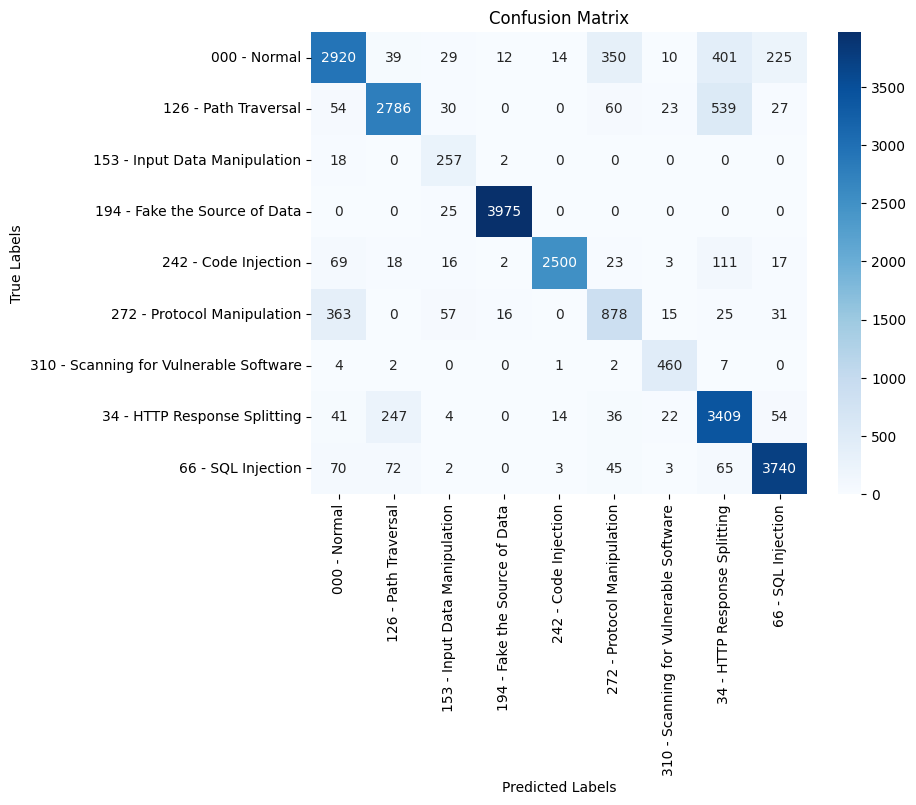

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Dự đoán trên tập test
y_pred = model.predict(x_test)

# Chuyển đổi các dự đoán về dạng nhãn
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Sử dụng LabelEncoder để chuyển đổi nhãn số về tên nhãn
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_test_labels = label_encoder.inverse_transform(y_test_classes)

# Tính ma trận nhầm lẫn
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

# Hiển thị ma trận nhầm lẫn dưới dạng đồ thị
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
